# Day 31 - Customer Churn Random Forest

## 학습 주제

Day 29와 Day 30에서 사용한 동일한 고객 이탈 데이터를 이용하여
Random Forest 분류 모델을 학습한다.

이번 분석에서는 다음 내용을 확인한다.

- Random Forest
- Ensemble
- Multiple Decision Trees
- n_estimators
- Train / Test Performance
- Overfitting
- Feature Importance

## 분석 질문

1. 여러 Decision Tree를 결합하면 단일 Tree와 어떤 차이가 있는가?
2. Random Forest도 Train 데이터에 과적합될 수 있는가?
3. Tree의 깊이를 제한하면 Train/Test 성능 차이는 어떻게 변하는가?
4. Random Forest의 분류 성능은 어느 정도인가?
5. 어떤 Feature가 Random Forest의 분류에 상대적으로 많이 사용되는가?

## 데이터

Day 29 Logistic Regression과 Day 30 Decision Tree에서 사용한
동일한 가상 고객 데이터를 사용한다.

입력 파일:

`data/raw/day29_customer_churn_classification.csv`

Target:

- 0: 향후 30일 유지
- 1: 향후 30일 이탈

동일한 데이터와 동일한 Train/Test 분할을 유지하여
모델 구조에 따른 차이를 확인한다.

In [2]:
# 라이브러리, 모듈, 함수 불러오기
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [3]:
# Path 경로 설정
project_root = Path.cwd().parent

input_path = (
    project_root
    / "data"
    / "raw"
    / "Day29_customer_churn_classification.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents = True,
    exist_ok = True
)

print(
    input_path
)

print(
    output_dir
)

d:\Study\Projects\00_foundation_review\data\raw\Day29_customer_churn_classification.csv
d:\Study\Projects\00_foundation_review\outputs


In [4]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(df.head())
print(df.shape)

   customer_id  login_days_30d  order_count_90d  support_tickets_90d  \
0            1               2                3                    5   
1            2              23                4                    3   
2            3              20                3                    3   
3            4              13                1                    5   
4            5              13                1                    0   

   membership_months  days_since_last_login  billing_issue_count_90d  \
0                 36                     11                        1   
1                 20                     38                        0   
2                 58                     28                        1   
3                 44                     15                        0   
4                 45                     28                        1   

   next_30d_churn  
0               1  
1               1  
2               0  
3               0  
4               1  
(800, 8)


In [5]:
print(df.dtypes)
print(df.isna().sum())
print(
    df["next_30d_churn"]
    .value_counts()
)

customer_id                int64
login_days_30d             int64
order_count_90d            int64
support_tickets_90d        int64
membership_months          int64
days_since_last_login      int64
billing_issue_count_90d    int64
next_30d_churn             int64
dtype: object
customer_id                0
login_days_30d             0
order_count_90d            0
support_tickets_90d        0
membership_months          0
days_since_last_login      0
billing_issue_count_90d    0
next_30d_churn             0
dtype: int64
next_30d_churn
0    478
1    322
Name: count, dtype: int64


In [6]:
# Feature, Target 나누기
feature = [
    "login_days_30d",
    "order_count_90d",
    "support_tickets_90d",
    "membership_months",
    "days_since_last_login",
    "billing_issue_count_90d"
]

X = df[
    feature
]

y = df[
    "next_30d_churn"
]

print(X.head())
print(y.head())

   login_days_30d  order_count_90d  support_tickets_90d  membership_months  \
0               2                3                    5                 36   
1              23                4                    3                 20   
2              20                3                    3                 58   
3              13                1                    5                 44   
4              13                1                    0                 45   

   days_since_last_login  billing_issue_count_90d  
0                     11                        1  
1                     38                        0  
2                     28                        1  
3                     15                        0  
4                     28                        1  
0    1
1    1
2    0
3    0
4    1
Name: next_30d_churn, dtype: int64


In [7]:
# Train, Test 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(600, 6)
(200, 6)
(600,)
(200,)


## Unlimited Random Forest

먼저 개별 Tree의 깊이를 제한하지 않은 Random Forest를 학습한다.

Random Forest가 여러 Tree를 결합하는 모델이라고 해도
과적합이 자동으로 사라지는 것은 아니다.

Train Accuracy와 Test Accuracy를 비교하여 확인한다.

In [8]:
unlimited_forest = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)

unlimited_forest.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
unlimited_train_prediction = unlimited_forest.predict(
    X_train
)
unlimited_test_prediction = unlimited_forest.predict(
    X_test
)

unlimited_train_accuracy = accuracy_score(
    y_train,
    unlimited_train_prediction
)
unlimited_test_accuracy = accuracy_score(
    y_test,
    unlimited_test_prediction
)

print(unlimited_train_prediction.mean())
print(unlimited_test_prediction.mean())
print(f"{unlimited_train_accuracy:.3f}")
print(f"{unlimited_test_accuracy:.3f}")

0.4033333333333333
0.355
1.000
0.705


## Unlimited Forest 해석

깊이를 제한하지 않은 Random Forest는 여러 Decision Tree를 결합하지만
Train 데이터에서 매우 높은 정확도를 보였다.

Random Forest는 단일 Decision Tree보다 과적합을 줄이는 경우가 많지만,
과적합을 완전히 제거하는 모델은 아니다.

따라서 Random Forest에서도 Train 성능과 Test 성능을 함께 확인해야 한다.

## Limited Random Forest

개별 Decision Tree의 최대 깊이를 6으로 제한한다.

Day 30에서 학습한 max_depth를 Random Forest 내부의
각 Decision Tree에도 적용한다.

모델 복잡도를 제한했을 때 Train/Test 성능 차이가 어떻게 변하는지 확인한다.

In [22]:
forest_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 6,
    random_state = 42
)

forest_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [23]:
forest_train_prediction = forest_model.predict(
    X_train
)
forest_test_prediction = forest_model.predict(
    X_test
)

forest_train_accuracy = accuracy_score(
    y_train,
    forest_train_prediction
)
forest_test_accuracy = accuracy_score(
    y_test,
    forest_test_prediction
)

print(forest_train_prediction.mean())
print(forest_test_prediction.mean())
print(f"Train Accuracy: {forest_train_accuracy:.3f}")
print(f"Test Accuracy: {forest_test_accuracy:.3f}")

0.38
0.375
Train Accuracy: 0.837
Test Accuracy: 0.725


In [24]:
# 분류지표
precision = precision_score(
    y_test,
    forest_test_prediction
)

recall = recall_score(
    y_test,
    forest_test_prediction
)

f1 = f1_score(
    y_test,
    forest_test_prediction
)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")

Precision: 0.667
Recall: 0.625
F1: 0.645


In [ ]:
# confusion matrix
confusion = confusion_matrix(
    y_test,
    forest_test_prediction
)

confusion_df = pd.DataFrame(
    confusion,
    index = [
        "actual 0",
        "actual 1"
    ],
    columns = [
        "predicted 0",
        "predicted 1"
    ]
)

print(confusion_df)

# TN : 95
# FP : 25
# FN : 30
# TP : 50

          predicted 0  predicted 1
actual 0           95           25
actual 1           30           50


In [30]:
# 예측확률 저장
probability = forest_model.predict_proba(
    X_test
)

churn_probability = (
    probability[
        :,
        1
    ]
)

print(churn_probability[:10])

[0.5314282  0.35321995 0.58990278 0.24557272 0.15119107 0.40383022
 0.65803469 0.26646113 0.73567818 0.66435833]


## Feature Importance

Random Forest의 `feature_importances_`를 이용하여
각 Feature가 Tree의 분할 과정에 얼마나 상대적으로 기여했는지 확인한다.

Feature Importance는 예측 모델 내부의 상대적 중요도를 나타내며
인과관계를 의미하지 않는다.

또한 중요도 값만으로 Feature 값이 증가할 때
이탈확률이 증가하는지 감소하는지는 알 수 없다.

In [39]:
feature_importance_df = pd.DataFrame(
    {
        "feature" : feature,
        "importance" : forest_model.feature_importances_
    }
)

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending = False
    )
)

feature_importance_df["importance"] = round(feature_importance_df["importance"] , 3)

feature_importance_df

,feature,importance
4,days_since_last_login,0.391
3,membership_months,0.169
0,login_days_30d,0.166
5,billing_issue_count_90d,0.104
1,order_count_90d,0.102
2,support_tickets_90d,0.069


<function matplotlib.pyplot.show(close=None, block=None)>

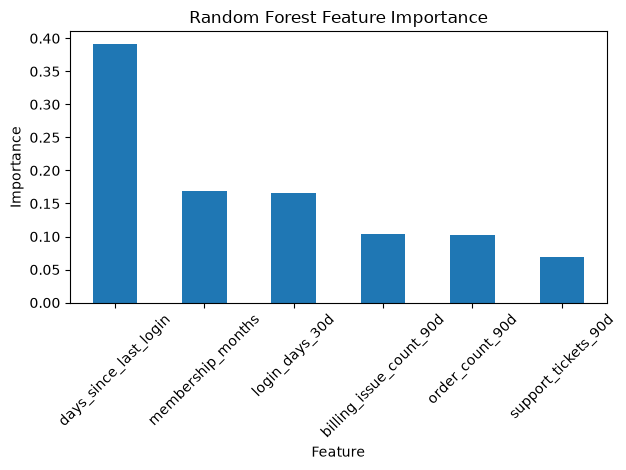

In [42]:
# Feature Importance 그래프
feature_importance_path = (
    output_dir
    / "customer_churn_random_forest_feature_importance.png"
)

feature_importance_df.plot.bar(
    x = "feature",
    y = "importance",
    legend = False
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Feature"
)

plt.xticks(
    rotation = 45
)

plt.ylabel(
    "Importance"
)

plt.tight_layout()

plt.savefig(
    feature_importance_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show

In [44]:
# Train/Test 비교표
metrics_df = pd.DataFrame(
    {
        "model" : [
            "unlimited_forest",
            "max_depth_6_forest"
        ],
        "train_accuracy" : [
            round(unlimited_train_accuracy, 3),
            round(forest_train_accuracy, 3)
        ],
        "test_accuracy" : [
            unlimited_test_accuracy,
            forest_test_accuracy
        ]
    }
)

print(metrics_df)

                model  train_accuracy  test_accuracy
0    unlimited_forest           1.000          0.705
1  max_depth_6_forest           0.837          0.725


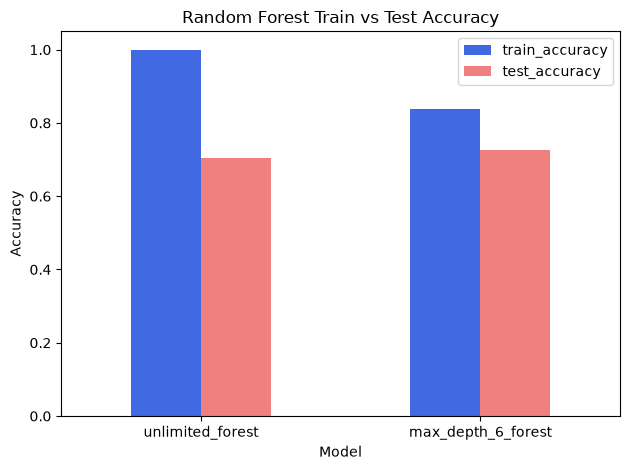

In [55]:
# Train/Test 비교 그래프
comparison_figure_path = (
    output_dir
    / "customer_churn_random_forest_train_test_comparison.png"
)

metrics_df.plot.bar(
    x = "model",
    y = [
        "train_accuracy",
        "test_accuracy"
    ],
    color = ["royalblue", "lightcoral"]
)

plt.title(
    "Random Forest Train vs Test Accuracy"
)

plt.xlabel(
    "Model"
)

plt.xticks(
    rotation = 0
)

plt.ylabel(
    "Accuracy"
)

plt.tight_layout()

plt.savefig(
    comparison_figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [59]:
# 고객별 Prediction 저장
prediction_df = pd.DataFrame(
    {
        "customer_id" : df.loc[
            X_test.index,
            "customer_id"
        ],
        "actual_churn" : y_test
    }
)

prediction_df[
    "predicted_churn"
] = forest_test_prediction

prediction_df[
    "predicted_churn_probability"
] = churn_probability.round(3)

print(prediction_df.head())

     customer_id  actual_churn  predicted_churn  predicted_churn_probability
677          678             0                1                        0.531
403          404             0                0                        0.353
206          207             1                1                        0.590
795          796             0                0                        0.246
788          789             0                0                        0.151


In [60]:
# csv 저장
metrics_path = (
    output_dir
    / "customer_churn_random_forest_metrics.csv"
)

confusion_path = (
    output_dir
    / "customer_churn_random_forest_confusion_matrix.csv"
)

prediction_path = (
    output_dir
    / "customer_churn_random_forest_predictions.csv"
)

feature_importance_path = (
    output_dir
    / "customer_churn_random_forest_feature_importance.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

confusion_df.to_csv(
    confusion_path
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

print(
    metrics_path
)

print(
    confusion_path
)

print(
    prediction_path
)

print(
    feature_importance_path
)

d:\Study\Projects\00_foundation_review\outputs\customer_churn_random_forest_metrics.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_random_forest_confusion_matrix.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_random_forest_predictions.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_random_forest_feature_importance.csv


## 최종 해석

### 제한 없는 Random Forest

- Train Accuracy: 1.000
- Test Accuracy: 0.705

깊이를 제한하지 않은 Random Forest는 여러 Decision Tree를 결합했지만
Train 데이터에서 매우 높은 정확도를 보였다.

Random Forest가 단일 Tree보다 안정적인 모델이라고 해도
과적합 여부를 확인할 필요가 있다는 점을 확인했다.

### max_depth=6 Random Forest

- Train Accuracy: 0.837
- Test Accuracy: 0.725
- Precision: 0.667
- Recall: 0.625
- F1 Score: 0.645

개별 Tree의 깊이를 제한한 결과 Train 데이터에 대한 적합 정도는 감소했고,
Train과 Test 성능 차이도 제한 없는 Forest보다 감소했다.

### Feature Importance

가장 높은 Feature Importance:

- days_since_last_login

Random Forest의 Feature Importance는 모델의 분할 과정에서
각 Feature가 상대적으로 얼마나 활용됐는지를 보여준다.

중요도가 높다고 해서 해당 Feature가 고객 이탈의 원인이라는 뜻은 아니며,
중요도만으로 관계의 증가·감소 방향을 판단할 수도 없다.

### 모델 해석

Random Forest는 여러 Decision Tree를 결합하여
단일 Tree의 불안정성을 줄이는 Ensemble 모델이다.

그러나 이번 데이터에서는 더 복잡한 Random Forest가
기존 Logistic Regression보다 반드시 더 높은 Test 성능을 보이지는 않았다.

따라서 모델 선택에서는 복잡성뿐 아니라
성능, 설명 가능성, 운영 목적을 함께 고려해야 한다.

### 한계

이번 데이터는 머신러닝 학습 목적으로 생성된 가상 데이터다.

Feature Importance는 모델 내부의 상대적 중요도이며
인과효과를 의미하지 않는다.

이번 실습에서는 Test 데이터를 학습 개념 확인에 반복 사용했으므로
실제 모델 선택 절차로 해석해서는 안 된다.

실제 모델 선택에서는 Validation 데이터 또는 Cross Validation이 필요하다.